# Example 19: Time-Domain vs Equivalent Linear Analysis

This example compares two approaches to site response analysis:

1. **Equivalent Linear (EQL)**: An iterative frequency-domain approach that approximates nonlinear soil behavior by iterating on strain-compatible shear modulus and damping.

2. **Frequency-dependent moduli EQL**: An iterative frequency-domain approach with frequency-dependent properties.

3. **Time-Domain (TD)**: A true nonlinear approach that integrates the wave equation directly in the time domain, capturing hysteretic soil behavior through constitutive models.



In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pystrata

%matplotlib inline

In [2]:
# Increased figure sizes
plt.rcParams["figure.dpi"] = 120

## Load Input Motion

We load a recorded earthquake time series. Time-domain analysis requires actual time series data (cannot use RVT).

In [3]:
fname = "data/NIS090.AT2"
ts = pystrata.motion.TimeSeriesMotion.load_at2_file(fname)

print(f"Motion: {ts.description}")
print(f"PGA: {ts.pga:.3f} g")
print(f"Duration: {ts.times[-1]:.1f} s")

Motion: KOBE 01/16/95 2046, NISHI-AKASHI, 090 (CUE)
PGA: 0.503 g
Duration: 41.0 s


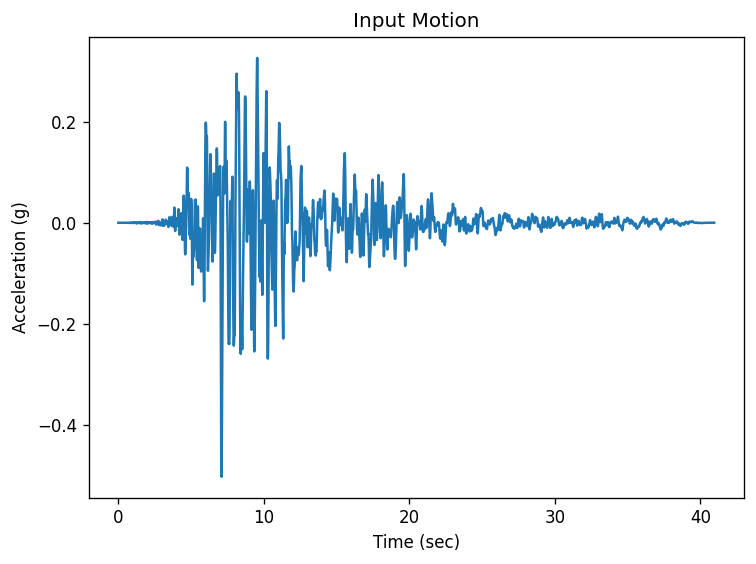

In [4]:
fig, ax = plt.subplots()
ax.plot(ts.times, ts.accels)
ax.set(xlabel="Time (sec)", ylabel="Acceleration (g)")
ax.set_title("Input Motion")
fig.tight_layout()

## Create Site Profile

We create a soil profile with nonlinear properties using the Darendeli model. This provides both modulus reduction and damping curves that both methods will use.

In [5]:
profile = pystrata.site.Profile(
    [
        pystrata.site.Layer(
            pystrata.site.DarendeliSoilType(
                unit_wt=18.0,
                plas_index=30,
                ocr=1,
                stress_mean=50,  # kPa - shallow depth
            ),
            thickness=10,
            shear_vel=150,
        ),
        pystrata.site.Layer(
            pystrata.site.DarendeliSoilType(
                unit_wt=19.0,
                plas_index=20,
                ocr=1,
                stress_mean=150,  # kPa - intermediate depth
            ),
            thickness=20,
            shear_vel=250,
        ),
        pystrata.site.Layer(
            pystrata.site.SoilType("Rock", 24.0, None, 0.01),
            thickness=0,  # Half-space
            shear_vel=800,
        ),
    ]
    # Discretize profile for strain compatiability within EQL and time-domain analyses
).auto_discretize(max_freq=100)

Text(0.5, 1.0, 'Site Profile')

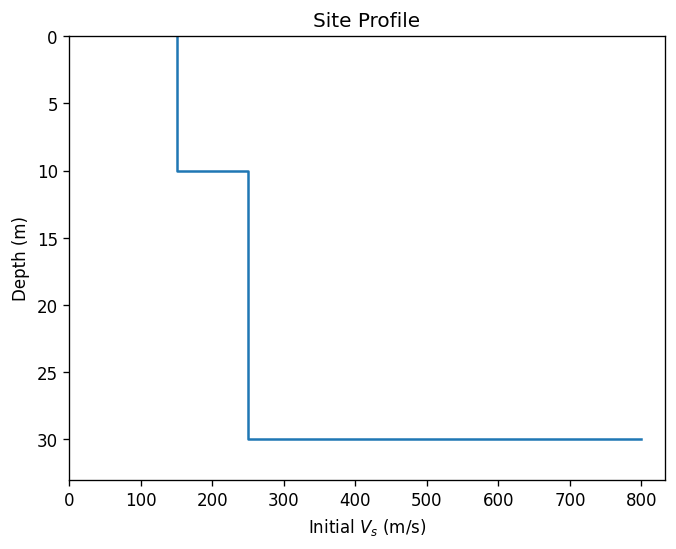

In [6]:
ax = profile.plot("initial_shear_vel")
ax.set_title("Site Profile")

## Create Calculators

We create both an Equivalent Linear calculator and a Time-Domain calculator.

The Time-Domain calculator uses the HH (Hybrid Hyperbolic) constitutive model, which is fitted to the nonlinear curves from the profile.

In [7]:
calcs = {
    "EQL": pystrata.propagation.EquivalentLinearCalculator(strain_ratio=0.65),
    "FDM": pystrata.propagation.FrequencyDependentEqlCalculator(),
    "TD-HH": pystrata.propagation.TimeDomainCalculator(
        model="hh", boundary="elastic", fit_mode="double", damp_form="liu_archuleta"
    ),
}

## Define Outputs

We focus on response spectra at the surface to compare the two methods.

In [8]:
freqs = np.logspace(-1, 2, num=200)

outputs = pystrata.output.OutputCollection(
    [
        pystrata.output.ResponseSpectrumOutput(
            freqs,
            pystrata.output.OutputLocation("outcrop", index=0),
            0.05,  # 5% damping
        ),
        pystrata.output.ResponseSpectrumRatioOutput(
            freqs,
            pystrata.output.OutputLocation("outcrop", index=-1),  # Input
            pystrata.output.OutputLocation("outcrop", index=0),  # Output (surface)
            0.05,
        ),
        pystrata.output.AccelTransferFunctionOutput(
            freqs,
            pystrata.output.OutputLocation("outcrop", index=-1),
            pystrata.output.OutputLocation("outcrop", index=0),
        ),
        pystrata.output.MaxStrainProfile(),
    ]
)

## Run Analyses

Run both calculators and collect outputs.

In [9]:
for name, calc in calcs.items():
    print(f"Running {name}...")
    loc_input = profile.location("outcrop", index=-1)
    calc(ts, profile, loc_input)
    outputs(calc, name)
    print("  Completed.")

Running EQL...
  Completed.
Running FDM...
  Completed.
Running TD-HH...
  Completed.


## Compare Response Spectra

The acceleration response spectrum shows the maximum response of single-degree-of-freedom oscillators at different natural frequencies. This is a key engineering quantity for structural design.

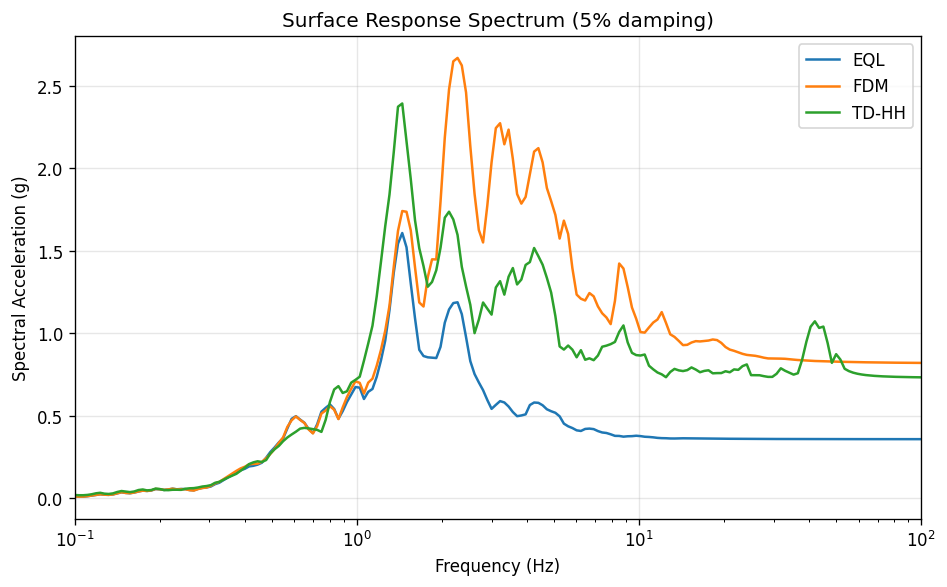

In [10]:
# Plot response spectrum
fig, ax = plt.subplots(figsize=(8, 5))

output_rs = outputs[0]  # ResponseSpectrumOutput
for name, refs, values in output_rs.iter_results():
    ax.plot(refs, values, label=name, linewidth=1.5)

ax.set(
    xlabel="Frequency (Hz)",
    ylabel="Spectral Acceleration (g)",
    xscale="log",
    xlim=(0.1, 100),
)
ax.legend()
ax.set_title("Surface Response Spectrum (5% damping)")
ax.grid(True, alpha=0.3)
fig.tight_layout()

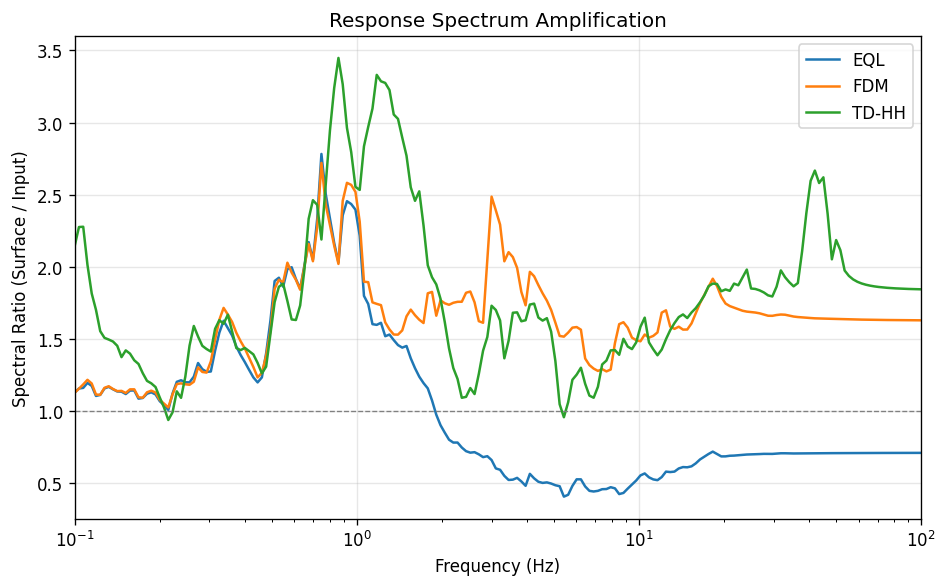

In [13]:
# Plot response spectrum ratio (amplification)
fig, ax = plt.subplots(figsize=(8, 5))

output_ratio = outputs[1]  # ResponseSpectrumRatioOutput
for name, refs, values in output_ratio.iter_results():
    ax.plot(refs, values, label=name, linewidth=1.5)

ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
ax.set(
    xlabel="Frequency (Hz)",
    ylabel="Spectral Ratio (Surface / Input)",
    xscale="log",
    xlim=(0.1, 100),
)
ax.legend()
ax.set_title("Response Spectrum Amplification")
ax.grid(True, alpha=0.3)
fig.tight_layout()

## Compare Transfer Functions

The transfer function shows how different frequencies are amplified or attenuated through the soil column.

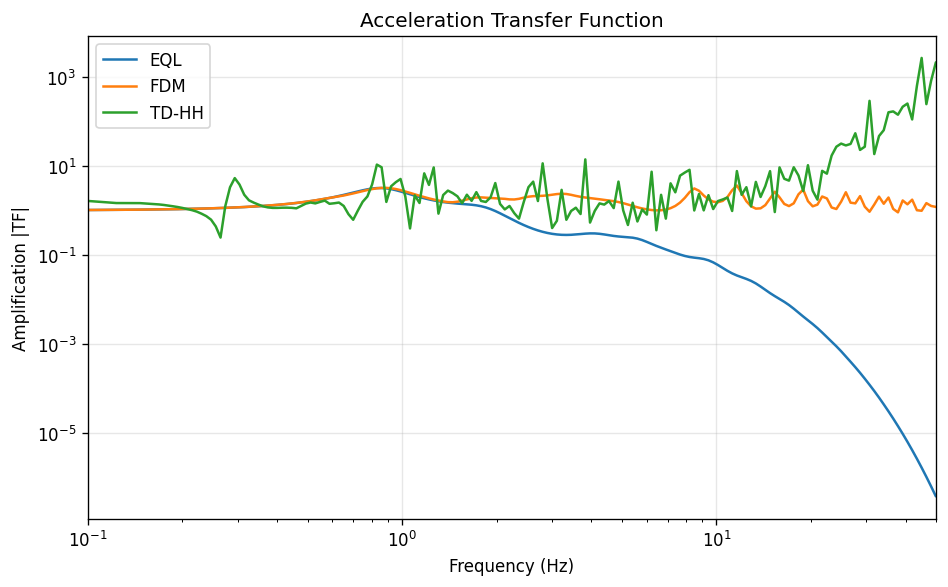

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

output_tf = outputs[2]  # AccelTransferFunctionOutput
for name, refs, values in output_tf.iter_results():
    ax.plot(refs, np.abs(values), label=name, linewidth=1.5)

ax.set(
    xlabel="Frequency (Hz)",
    ylabel="Amplification |TF|",
    yscale="log",
    xscale="log",
    xlim=(0.1, 50),
)
ax.legend()
ax.set_title("Acceleration Transfer Function")
ax.grid(True, alpha=0.3)
fig.tight_layout()

## Compare Maximum Strain Profiles

The maximum shear strain at each depth indicates the level of nonlinearity mobilized in the soil.

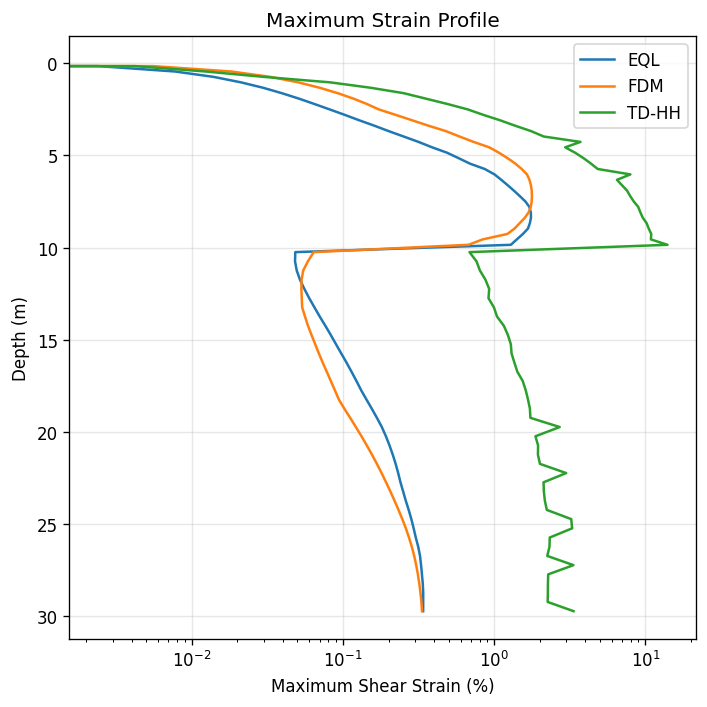

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))

output_strain = outputs[3]  # MaxStrainProfile
for name, refs, values in output_strain.iter_results():
    ax.plot(values * 100, refs, label=name, linewidth=1.5)

ax.set(
    xlabel="Maximum Shear Strain (%)",
    ylabel="Depth (m)",
    xscale="log",
)
ax.invert_yaxis()
ax.legend()
ax.set_title("Maximum Strain Profile")
ax.grid(True, alpha=0.3)
fig.tight_layout()

## Time History Comparison

Compare the surface acceleration time histories from both methods.

In [16]:
# Get surface acceleration from time-domain calculator
calc_td = calcs["TD-HH"]
loc_surface = profile.location("outcrop", index=0)
accel_td = calc_td.accel_ts(loc_surface)
times_td = calc_td.times

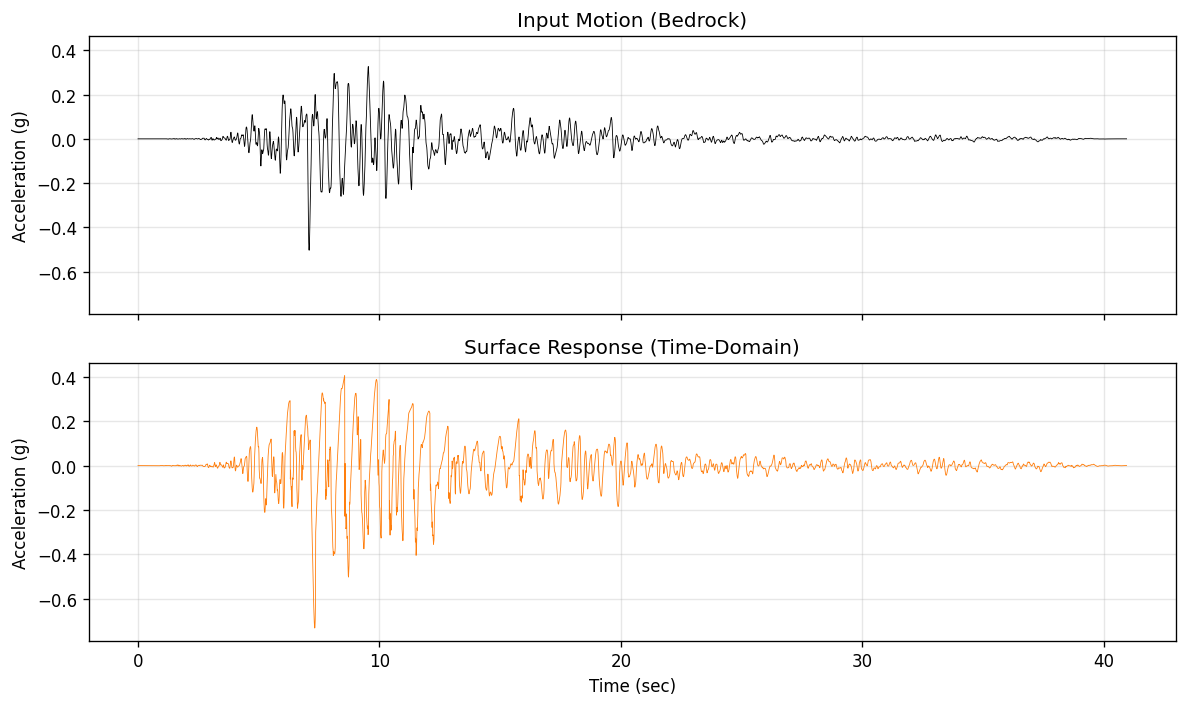

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)

# Input motion
axes[0].plot(ts.times, ts.accels, "k", linewidth=0.5)
axes[0].set(ylabel="Acceleration (g)")
axes[0].set_title("Input Motion (Bedrock)")

# Surface response from TD
axes[1].plot(times_td, accel_td, "C1", linewidth=0.5)
axes[1].set(xlabel="Time (sec)", ylabel="Acceleration (g)")
axes[1].set_title("Surface Response (Time-Domain)")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.tight_layout()

In [18]:
# Print summary statistics
print("Peak Ground Acceleration (PGA) Summary:")
print(f"  Input:        {ts.pga:.4f} g")
print(f"  TD Surface:   {np.max(np.abs(accel_td)):.4f} g")
print(f"  Amplification: {np.max(np.abs(accel_td)) / ts.pga:.2f}x")

Peak Ground Acceleration (PGA) Summary:
  Input:        0.5027 g
  TD Surface:   0.7331 g
  Amplification: 1.46x
